# Problem Title - Library Mode
Issue: #<issue-number>8

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [108]:
import torch
from torch import nn
import pandas as pd

In [109]:
# Set device agnostic
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [ ]:
df = pd.read_csv("../dataset.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [112]:
df['quality'].nunique(), df['quality_binary'].nunique()

(7, 2)

In [113]:
df.columns, len(df.columns)

(Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary'],
       dtype='object'),
 13)

## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [114]:
X = df[['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
        'pH', 'sulphates', 'alcohol']]

y = df['quality_binary']

X[:5], y[:5]

(   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
 0            7.4              0.70         0.00             1.9      0.076   
 1            7.8              0.88         0.00             2.6      0.098   
 2            7.8              0.76         0.04             2.3      0.092   
 3           11.2              0.28         0.56             1.9      0.075   
 4            7.4              0.70         0.00             1.9      0.076   
 
    free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
 0                 11.0                  34.0   0.9978  3.51       0.56   
 1                 25.0                  67.0   0.9968  3.20       0.68   
 2                 15.0                  54.0   0.9970  3.26       0.65   
 3                 17.0                  60.0   0.9980  3.16       0.58   
 4                 11.0                  34.0   0.9978  3.51       0.56   
 
    alcohol  
 0      9.4  
 1      9.8  
 2      9.8  
 3      9.8  
 4

In [115]:
X_data_tensor = torch.from_numpy(X.values).to(device)
y_data_tensor = torch.from_numpy(y.values).to(device)

X_data_tensor, y_data_tensor

(tensor([[ 7.4000,  0.7000,  0.0000,  ...,  3.5100,  0.5600,  9.4000],
         [ 7.8000,  0.8800,  0.0000,  ...,  3.2000,  0.6800,  9.8000],
         [ 7.8000,  0.7600,  0.0400,  ...,  3.2600,  0.6500,  9.8000],
         ...,
         [ 6.5000,  0.2400,  0.1900,  ...,  2.9900,  0.4600,  9.4000],
         [ 5.5000,  0.2900,  0.3000,  ...,  3.3400,  0.3800, 12.8000],
         [ 6.0000,  0.2100,  0.3800,  ...,  3.2600,  0.3200, 11.8000]],
        dtype=torch.float64),
 tensor([0, 0, 0,  ..., 0, 1, 0]))

In [116]:
X_data_tensor.shape, y_data_tensor.shape

(torch.Size([6497, 11]), torch.Size([6497]))

In [117]:
X_data_tensor[0]

tensor([ 7.4000,  0.7000,  0.0000,  1.9000,  0.0760, 11.0000, 34.0000,  0.9978,
         3.5100,  0.5600,  9.4000], dtype=torch.float64)

In [118]:
input_shape = X_data_tensor[0].shape
input_shape

torch.Size([11])

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data_tensor, y_data_tensor, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

(tensor([[6.6000e+00, 2.4000e-01, 3.5000e-01,  ..., 3.1900e+00, 3.7000e-01,
          1.0500e+01],
         [8.3000e+00, 2.8000e-01, 4.8000e-01,  ..., 3.2600e+00, 6.2000e-01,
          1.2400e+01],
         [7.7000e+00, 7.1500e-01, 1.0000e-02,  ..., 3.4100e+00, 5.7000e-01,
          1.1800e+01],
         ...,
         [6.4000e+00, 3.7000e-01, 2.0000e-01,  ..., 3.2400e+00, 4.3000e-01,
          9.5000e+00],
         [6.5000e+00, 2.6000e-01, 5.0000e-01,  ..., 3.1800e+00, 4.7000e-01,
          9.5000e+00],
         [7.2000e+00, 6.2000e-01, 6.0000e-02,  ..., 3.5100e+00, 5.4000e-01,
          9.5000e+00]], dtype=torch.float64),
 tensor([[ 7.0000,  0.1700,  0.7400,  ...,  3.2600,  0.3800, 12.2000],
         [ 7.7000,  0.6400,  0.2100,  ...,  3.2700,  0.4500,  9.9000],
         [ 6.8000,  0.3900,  0.3400,  ...,  3.1800,  0.4400, 12.0000],
         ...,
         [ 6.6000,  0.1600,  0.3500,  ...,  3.1900,  0.7500, 12.4000],
         [ 6.6000,  0.3900,  0.3800,  ...,  3.3000,  0.5700,  9.4000],


In [120]:
X_train.shape

torch.Size([5197, 11])

## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [121]:
class Model(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.block_1(x)

In [137]:
model = Model(input_shape=11, hidden_units=8, output_shape=1).to(device)
model

Model(
  (block_1): Sequential(
    (0): Linear(in_features=11, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [138]:
try:
  import torchmetrics
except:
  !pip install torchmetrics
  import torchmetrics

In [139]:
# Set the loss function, accuracy function and optimizer
from torchmetrics import Accuracy

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.1)
accuracy_fn = Accuracy(task='binary', num_classes=1)

In [140]:
# Training Loop
epochs = 50

X_train, X_test, y_train, y_test = X_train.to(device).to(torch.float32), X_test.to(device).to(torch.float32), y_train.to(device).to(torch.float32), y_test.to(device).to(torch.float32)

train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []
epoch_count = []

for epoch in range(epochs):
  # set the mode to train
  model.train()

  y_logits = model(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate the loss and accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_pred, y_train)

  # Optimizer zero grad
  optimizer.zero_grad()

  # Backpropagation
  loss.backward()

  # Optimizer step
  optimizer.step()

  # Testing loop
  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    train_accuracies.append(acc.item())
    test_accuracies.append(test_acc.item())
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    print(f"Epoch : {epoch} | Loss : {loss:.3f} | Test Loss : {test_loss:.3f} | Accuracy : {acc:.2f}% | Test Accuracy : {test_acc:.2f}%")

Epoch : 0 | Loss : 3.746 | Test Loss : 1.970 | Accuracy : 0.20% | Test Accuracy : 0.81%
Epoch : 10 | Loss : 0.663 | Test Loss : 0.648 | Accuracy : 0.76% | Test Accuracy : 0.79%
Epoch : 20 | Loss : 0.553 | Test Loss : 0.542 | Accuracy : 0.80% | Test Accuracy : 0.81%
Epoch : 30 | Loss : 0.500 | Test Loss : 0.494 | Accuracy : 0.80% | Test Accuracy : 0.81%
Epoch : 40 | Loss : 0.498 | Test Loss : 0.493 | Accuracy : 0.80% | Test Accuracy : 0.81%


In [141]:
train_accuracies

[0.19722917675971985,
 0.7623628973960876,
 0.8027708530426025,
 0.8027708530426025,
 0.8027708530426025]

## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

In [142]:
import matplotlib.pyplot as plt

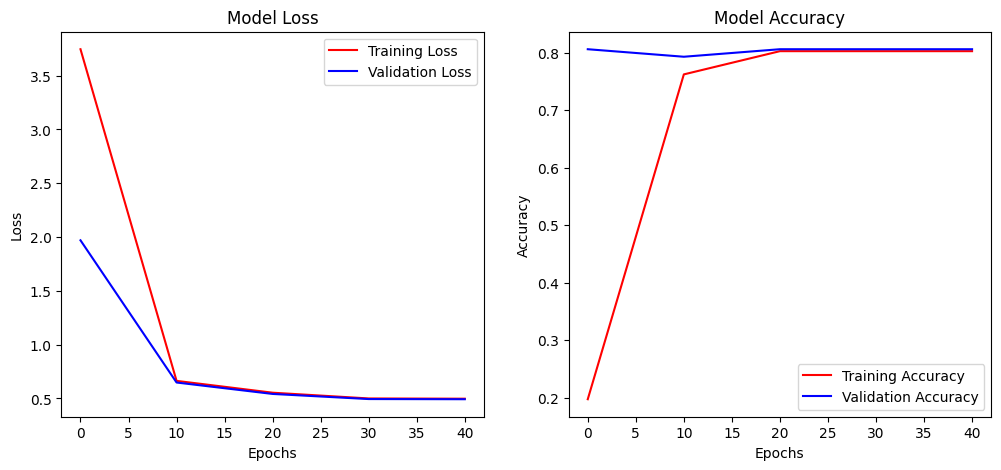

In [143]:
# Loss Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_count, train_losses, 'r', label='Training Loss')
plt.plot(epoch_count, test_losses, 'b', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epoch_count, train_accuracies, 'r', label='Training Accuracy')
plt.plot(epoch_count, test_accuracies, 'b', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

Ans 1) I didn't really remove any features from the dataset as it was a small dataset and it doesn't really seem necessary.

Ans 2) The model it generalizing quite well so it has a balanced fit.

Ans 3) Choosing the right learning rate influenced the result the most as when i used 0.01, i got accuracy upto 77% then when i used learning rate 0.1,  the i achieved 81% accuracy.